# Moment-Curvature Analysis

In this example a moment-curvature analysis is performed for a concrete section.

## Setup

In [2]:
import veux
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import xara
from xara.units.fks import kip, ksi

## Materials

In [4]:
Fcc = 6*ksi

materials = {
    "core": xara.Material(
        type= "Concrete01",
        Fc  =  Fcc,
        ec0 =  0.004,
        Fcu =  5*ksi,
        ecu =  0.014,
        nu  =  0.2
    ),
    "cover": xara.Material(
        type= "Concrete01",
        Fc  =  -5*ksi,
        ec0 = -0.002,
        Fcu =  0,
        ecu = -0.006,
        nu  =  0.2
    ),
    "rebar": xara.Material(
        type= "Steel01",
        nu  = 0.3,       # Poisson's ratio
        E   =  30e3*ksi, # Young's modulus
        Fy  =    60*ksi, # yield strength
        b   =     0.01,  # strain hardening ratio
    )
}


## Geometry

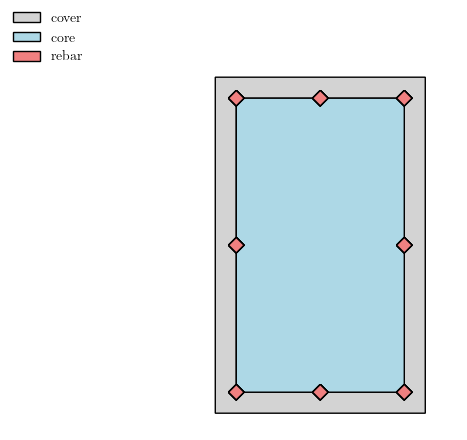

In [5]:
from xsection.library import Rectangle, Circle
from xsection import CompositeSection

h = 24
b = 15
d = 7/8
r = 0 #d/2

c = 1.5

bar = Circle(d/2, z=2, mesh_scale=1/2, divisions=4, group="rebar", material=materials["rebar"])

shape = CompositeSection([
    Rectangle(    b, h,     z=0, group="cover", material=materials["cover"]),
    Rectangle(b-2*c, h-2*c, z=1, group="core",  material=materials["core"]),
    *bar.linspace([-b/2+c+r, -h/2+c+r], [ b/2-c-r,-h/2+c+r], 3), # Top bars
    *bar.linspace([-b/2+c+r,        0], [ b/2-c-r,       0], 2), # Center bars
    *bar.linspace([-b/2+c+r,  h/2-c-r], [ b/2-c-r, h/2-c-r], 3)  # Bottom bars
])


veux.draw_shape(shape)

## Section

In [6]:
section = xara.Section("Fiber", shape)

## Analysis

In [7]:
from xsection.analysis import SectionInteraction

In [8]:
Pmax = 0.85*shape.area*Fcc

axial = np.linspace(-Pmax, Pmax*0.1, 15)

si = SectionInteraction(section, axial=axial)

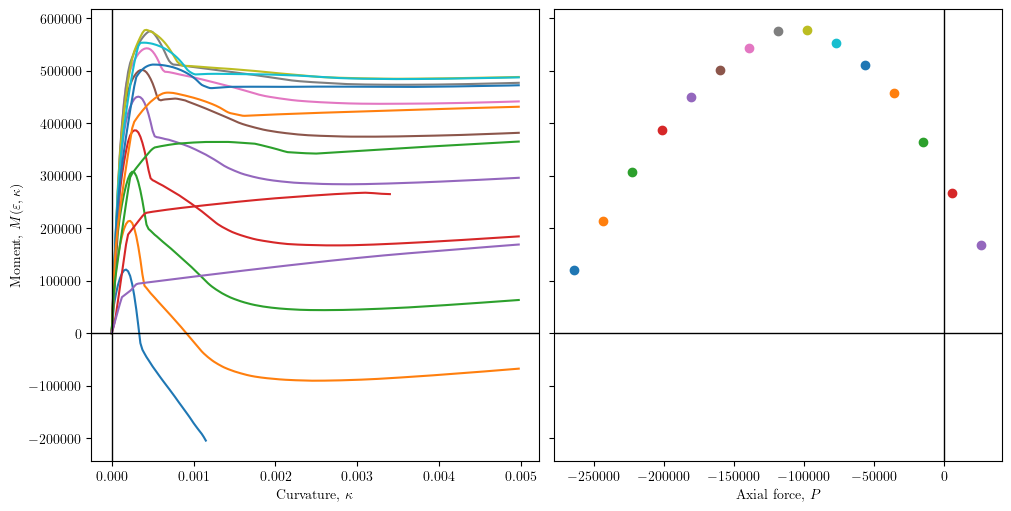

In [9]:
fig, ax = plt.subplots(1,2, sharey=True, constrained_layout=True, figsize=(10, 5))
mmax = []

for n, m, k in si.moment_curvature():
    ax[0].plot(k, m, '-')

    ax[1].plot([n], [max(m)], 'o')

ax[0].axvline(0, color="k", lw=1)
ax[0].axhline(0, color="k", lw=1)
ax[1].axvline(0, color="k", lw=1)
ax[1].axhline(0, color="k", lw=1)
ax[0].set_xlabel("Curvature, $\\kappa$")
ax[0].set_ylabel("Moment, $M(\\varepsilon, \\kappa)$")
ax[1].set_xlabel("Axial force, $P$");